DiGraph with 57771 nodes and 1094895 edges
resolution = 0.01
Counter({0: 1005, 1: 966, 2: 824, 3: 810, 4: 763, 5: 749, 6: 710, 7: 613, 8: 568, 9: 556, 10: 553, 11: 522, 12: 514, 13: 511, 14: 505, 15: 497, 16: 495, 17: 491, 18: 484, 19: 461, 20: 436, 21: 420, 22: 416, 23: 356, 24: 328, 25: 316, 26: 304, 27: 262, 28: 243, 29: 232, 30: 231, 31: 223, 32: 220, 33: 214, 34: 208, 35: 197, 36: 186, 37: 177, 38: 176, 39: 164, 40: 160, 41: 158, 42: 155, 43: 153, 45: 150, 44: 150, 46: 147, 47: 118, 48: 115, 49: 113, 50: 113, 51: 112, 52: 109, 53: 104, 54: 100, 55: 100, 56: 99, 57: 96, 58: 95, 59: 94, 60: 87, 61: 86, 62: 84, 63: 80, 64: 74, 65: 69, 66: 67, 67: 65, 68: 64, 69: 63, 70: 63, 75: 62, 77: 62, 76: 62, 74: 62, 71: 62, 78: 62, 73: 62, 72: 62, 82: 61, 79: 61, 80: 61, 81: 61, 83: 60, 85: 59, 84: 59, 86: 59, 87: 58, 88: 56, 89: 55, 90: 55, 91: 54, 93: 54, 92: 54, 94: 53, 95: 52, 96: 51, 100: 50, 99: 50, 101: 50, 97: 50, 102: 50, 98: 50, 103: 49, 104: 47, 106: 47, 105: 47, 110: 46, 107: 46, 11

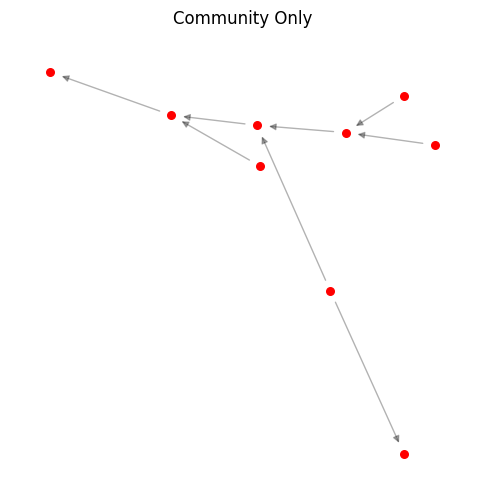

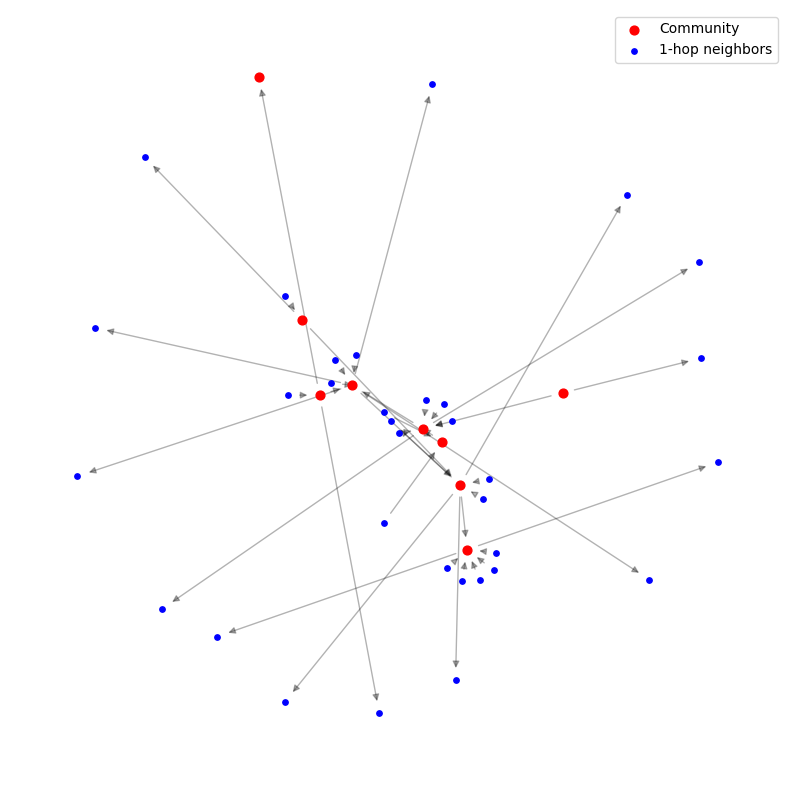

In [ ]:
import networkx as nx
import pickle
import igraph as ig
import leidenalg
import statistics
import matplotlib.pyplot as plt
from collections import Counter

# Visualize Example Community and one-hop neighbors

# ----------------------------
# Load NetworkX graph
# ----------------------------
with open("data/neuron_graph.gpickle", "rb") as f:
    G = pickle.load(f)

print(G)

# ----------------------------
# Convert to igraph (preserve node IDs)
# ----------------------------
g = ig.Graph.TupleList(
    G.edges(),
    directed=True,
    vertex_name_attr="name"
)

# ----------------------------
# Leiden partition
# ----------------------------
partitions = [0.01]
medians = []
lengths = []

for p in partitions:
    print("resolution =", p)

    partition = leidenalg.find_partition(
        g,
        leidenalg.CPMVertexPartition,
        resolution_parameter=p
    )

    print(Counter(partition.membership))

    sizes = list(Counter(partition.membership).values())
    medians.append(statistics.median(sizes))

    communities = [
        [g.vs[v]["name"] for v in community]
        for community in partition
    ]

    lengths.append(len(communities))
    print("num communities:", len(communities))

print("median sizes:", medians)
print("num communities:", lengths)

#Choose a single community
idx = int(len(communities) / 1.85)
community_nodes = set(communities[idx])

print("community size:", len(community_nodes))

#community nodes subgraph
C =G.subgraph(community_nodes).copy()
plt.figure(figsize=(6, 6))
pos_c = nx.spring_layout(C, seed=42)

nx.draw_networkx_edges(C, pos_c, alpha=0.3)
nx.draw_networkx_nodes(
    C,
    pos_c,
    node_color="red",
    node_size=30
)

plt.title("Community Only")
plt.axis("off")
plt.show()

#Find community and 1-hop neighbors
neighbors = set()
for n in community_nodes:
    neighbors.update(G.predecessors(n))
    neighbors.update(G.successors(n))

neighbors -= community_nodes

H = G.subgraph(community_nodes | neighbors).copy()

pos = nx.spring_layout(H, seed=42)

#Draw edge only connecting to community nodes
community_edges = [
    (u, v) for u, v in H.edges()
    if (u in community_nodes) or (v in community_nodes)
]

plt.figure(figsize=(10, 10))

nx.draw_networkx_edges(
    H,
    pos,
    edgelist=community_edges,
    alpha=0.3
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(community_nodes),
    node_color="red",
    node_size=40,
    label="Community"
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(neighbors),
    node_color="blue",
    node_size=15,
    label="1-hop neighbors"
)

plt.legend()
plt.axis("off")
plt.show()
